# 🐝 FJSP con PSO — Hurink + Brandimarte + Dauzère
Ejecuta las celdas **en orden de arriba hacia abajo**.


## 1 · Montar Google Drive

In [16]:
from google.colab import drive
drive.mount('/content/drive')
print('Drive montado.')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive montado.


## 2 · Configuración

- `TEST_MODE = True` → corrida rápida (~3 min) para verificar que todo funciona.
- `TEST_MODE = False` → corrida oficial completa (~3-4 horas).


In [17]:
import os, time, statistics, csv, glob
from datetime import datetime

# Rutas fijas a tu Drive
INST_ROOT  = "/content/drive/MyDrive/Enjambre de Particulas Con AMPL FINAL/instancias"
OUTPUT_DIR = "/content/drive/MyDrive/Enjambre de Particulas Con AMPL FINAL/resultados"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Verificar que existen
assert os.path.isdir(INST_ROOT), f"No encuentro la carpeta: {INST_ROOT}"
print(f"Instancias : {INST_ROOT}")
print(f"Resultados : {OUTPUT_DIR}")
print(f"Contenido  : {os.listdir(INST_ROOT)}")

# Modo de ejecucion
TEST_MODE = False

if TEST_MODE:
    TIME_BUDGET   = 5.0
    N_REPS        = 2
    HURINK_INST   = ["la01", "la16"]
    BRAND_INST    = ["Mk01", "Mk06"]
    DAUZ_INST     = ["01a", "13a"]
    print("\nTEST_MODE activo — corrida rapida de demostracion.")
    print("Para la corrida oficial cambia TEST_MODE = False.")
else:
    TIME_BUDGET   = 60.0
    N_REPS        = 5
    HURINK_INST   = ["la01","la06","la11","la16","la21"]
    BRAND_INST    = ["Mk01","Mk02","Mk03","Mk04","Mk05",
                     "Mk06","Mk07","Mk08","Mk09","Mk10"]
    DAUZ_INST     = ["01a","04a","07a","10a","13a","16a"]

SEED_BASE       = 100
SEEDS           = list(range(SEED_BASE, SEED_BASE + N_REPS))
HURINK_SUBSETS  = ["edata", "rdata", "vdata"]

PSO_PARAMS = dict(
    swarm_size=40, w_max=0.9, w_min=0.4,
    c1=1.6, c2=1.6, v_max=0.3, stagnation_limit=60
)

UB = {
    ("hurink_edata","la01"):609, ("hurink_edata","la06"):800,
    ("hurink_edata","la11"):1071,("hurink_edata","la16"):717,
    ("hurink_edata","la21"):835,
    ("hurink_rdata","la01"):570, ("hurink_rdata","la06"):799,
    ("hurink_rdata","la11"):1071,("hurink_rdata","la16"):717,
    ("hurink_rdata","la21"):833,
    ("hurink_vdata","la01"):570, ("hurink_vdata","la06"):799,
    ("hurink_vdata","la11"):1071,("hurink_vdata","la16"):717,
    ("hurink_vdata","la21"):800,
    ("brandimarte","Mk01"):42,  ("brandimarte","Mk02"):32,
    ("brandimarte","Mk03"):211, ("brandimarte","Mk04"):81,
    ("brandimarte","Mk05"):186, ("brandimarte","Mk06"):86,
    ("brandimarte","Mk07"):157, ("brandimarte","Mk08"):523,
    ("brandimarte","Mk09"):369, ("brandimarte","Mk10"):296,
    ("dauzere","01a"):2530, ("dauzere","04a"):2565,
    ("dauzere","07a"):2408, ("dauzere","10a"):2362,
    ("dauzere","13a"):2302, ("dauzere","16a"):2301,
}

def get_path(bench, name, subset=None):
    if bench == "hurink":
        return os.path.join(INST_ROOT, "Hurink_Data", subset, name + ".txt")
    elif bench == "brandimarte":
        return os.path.join(INST_ROOT, "Brandimarte_Data", "Text", name + ".fjs")
    else:
        return os.path.join(INST_ROOT, "dauzere", name + ".fjs")

def gap_pct(mk, ub):
    return float("nan") if not ub else round((mk - ub) / ub * 100, 3)

print(f"\nSemillas      : {SEEDS}")
print(f"Budget/ejec.  : {TIME_BUDGET} s")
print(f"Hurink        : {HURINK_INST}")
print(f"Brandimarte   : {BRAND_INST}")
print(f"Dauzere       : {DAUZ_INST}")


Instancias : /content/drive/MyDrive/Enjambre de Particulas Con AMPL FINAL/instancias
Resultados : /content/drive/MyDrive/Enjambre de Particulas Con AMPL FINAL/resultados
Contenido  : ['Hurink_Data', 'dauzere', 'Brandimarte_Data']

Semillas      : [100, 101, 102, 103, 104]
Budget/ejec.  : 60.0 s
Hurink        : ['la01', 'la06', 'la11', 'la16', 'la21']
Brandimarte   : ['Mk01', 'Mk02', 'Mk03', 'Mk04', 'Mk05', 'Mk06', 'Mk07', 'Mk08', 'Mk09', 'Mk10']
Dauzere       : ['01a', '04a', '07a', '10a', '13a', '16a']


## 3 · Algoritmo PSO (embebido)

In [18]:
# -*- coding: utf-8 -*-
"""
=============================================================================
 fjsp_pso.py
 -----------------------------------------------------------------------------
 Optimizacion Combinatoria - Flexible Job Shop Scheduling Problem (FJSP)
 Metaheuristica: OPTIMIZACION POR ENJAMBRE DE PARTICULAS (PSO)
 Objetivo: minimizar el makespan (Cmax).

 Este modulo contiene:
   1) Un parser para las instancias de Hurink (1994) en el formato de texto
      "old format" (subconjuntos edata / rdata / vdata).
   2) Un decodificador que, a partir de una particula (vector continuo),
      construye una planificacion factible (schedule activo con insercion en
      huecos) y calcula su makespan.
   3) Una implementacion de PSO de proposito general adaptada al FJSP.

 NOTA: Implementacion en Python PURO. Solo se usan modulos de la libreria
 estandar (random, time, math). Sin numpy ni dependencias externas.
=============================================================================
"""

import random
import time
import math


# 1) LECTURA DE INSTANCIAS (PARSER DEL FORMATO HURINK "old format")
#
# Estructura del archivo de texto:
#
#   Linea 1:  <n_jobs>  <n_machines>  <flexibilidad_promedio>
#   Linea i:  para cada job ->
#             <n_operaciones>  luego, por cada operacion:
#                 <k>  (cantidad de maquinas alternativas)
#                 seguido de k pares  (<maquina>, <tiempo>)
#
# Las maquinas en el archivo estan en BASE 1; internamente se convierten a
# BASE 0 para indexar listas comodamente.

class FJSPInstance:
    """Contenedor de una instancia de FJSP ya parseada.

    Atributos
    ---------
    name        : nombre identificador (p.ej. 'edata/la01')
    n_jobs      : numero de trabajos (jobs)
    n_machines  : numero de maquinas
    jobs        : lista de jobs. Cada job es una lista de operaciones.
                  Cada operacion es una lista de alternativas (machine, ptime),
                  con machine en BASE 0.
    n_ops       : numero total de operaciones de la instancia.
    op_index    : matriz de indices globales; op_index[j][o] = indice global
                  (0..n_ops-1) de la operacion o del job j.
    """

    def __init__(self, name, n_jobs, n_machines, jobs):
        self.name = name
        self.n_jobs = n_jobs
        self.n_machines = n_machines
        self.jobs = jobs
        self.n_ops = sum(len(j) for j in jobs)

        # Indice global de cada operacion (util para los vectores del PSO).
        self.op_index = []
        counter = 0
        for j in range(n_jobs):
            row = []
            for _o in range(len(jobs[j])):
                row.append(counter)
                counter += 1
            self.op_index.append(row)

        # Etiqueta de job para cada "slot" global (codificacion basada en
        # operaciones): el job j aparece tantas veces como operaciones tenga.
        # Al ordenar los slots por su clave continua se obtiene SIEMPRE una
        # secuencia factible respecto a la precedencia dentro de cada job.
        self.slot_job = []
        for j in range(n_jobs):
            for _o in range(len(jobs[j])):
                self.slot_job.append(j)


def parse_hurink(path, name=None):
    """Lee un archivo de instancia Hurink y devuelve un FJSPInstance.

    Parametros
    ----------
    path : ruta al archivo .txt
    name : nombre legible para la instancia (opcional)
    """
    with open(path, "r") as f:
        # Tokenizamos por lineas no vacias.
        lines = [ln.split() for ln in f if ln.strip()]

    header = lines[0]
    n_jobs = int(header[0])
    n_machines = int(header[1])
    # header[2] = flexibilidad promedio (informativa, no se usa para calcular).

    jobs = []
    for line in lines[1:1 + n_jobs]:
        # Algunos archivos usan tiempos enteros; convertimos de forma robusta.
        tok = [int(float(x)) for x in line]
        idx = 0
        n_ops = tok[idx]; idx += 1
        ops = []
        for _ in range(n_ops):
            k = tok[idx]; idx += 1          # nro de maquinas alternativas
            alts = []
            for _ in range(k):
                m = tok[idx] - 1            # maquina (base 1 -> base 0)
                p = tok[idx + 1]           # tiempo de procesamiento
                idx += 2
                alts.append((m, p))
            ops.append(alts)
        # Verificacion de integridad: deben consumirse todos los tokens.
        assert idx == len(tok), \
            "Error de parseo en %s: tokens sobrantes/faltantes" % path
        jobs.append(ops)

    if name is None:
        name = path
    return FJSPInstance(name, n_jobs, n_machines, jobs)


# 2) DECODIFICADOR  (particula continua  ->  schedule factible -> makespan)
#
# Cada particula tiene dimension 2*N (N = numero total de operaciones):
#
#   * Mitad MS (Machine Selection), valores en [0, 1):
#         para la operacion global g con L alternativas de maquina,
#         se elige la alternativa  floor(key * L)  (acotada a [0, L-1]).
#
#   * Mitad OS (Operation Sequence), valores reales (random keys):
#         se ordenan los "slots" por su clave; leyendo las etiquetas de job
#         (instance.slot_job) se obtiene una secuencia de jobs. La k-esima
#         aparicion del job j corresponde a su k-esima operacion. Esta
#         codificacion garantiza factibilidad de precedencia.
#
# La construccion del schedule usa INSERCION EN HUECOS (active schedule):
# cada operacion se coloca en el hueco factible mas temprano de su maquina,
# respetando que el job ya haya terminado su operacion anterior. Esto produce
# planificaciones de buena calidad (left-shifting) sin costo elevado.

def decode(instance, pos_ms, pos_os):
    """Decodifica una particula y devuelve (makespan, schedule).

    schedule : lista de tuplas (job, op, machine, start, end), util para
               auditar / depurar / dibujar diagramas de Gantt si se desea.
    """
    n_jobs = instance.n_jobs
    jobs = instance.jobs

    # (a) Obtener la secuencia de jobs a partir de la mitad OS
    # Ordenamos los indices de slot por su clave continua (estable).
    order = sorted(range(instance.n_ops), key=lambda s: pos_os[s])
    job_seq = [instance.slot_job[s] for s in order]

    # (b) Construir el schedule operacion por operacion
    # Estructuras de estado:
    next_op = [0] * n_jobs                 # proxima operacion pendiente por job
    job_ready = [0] * n_jobs               # instante en que el job queda libre
    # Intervalos ocupados por maquina: lista ordenada de (start, end).
    machine_intervals = [[] for _ in range(instance.n_machines)]

    makespan = 0
    schedule = []

    for j in job_seq:
        o = next_op[j]
        next_op[j] += 1
        g = instance.op_index[j][o]        # indice global de la operacion

        # Seleccion de maquina via mitad MS.
        alts = jobs[j][o]
        L = len(alts)
        sel = int(pos_ms[g] * L)
        if sel >= L:
            sel = L - 1
        elif sel < 0:
            sel = 0
        m, p = alts[sel]

        # Earliest start: cuando el job quedo libre (precedencia intra-job).
        est = job_ready[j]

        # Buscar el hueco factible mas temprano en la maquina m.
        intervals = machine_intervals[m]
        start = None
        prev_end = 0
        for (s, e) in intervals:
            cand = est if est > prev_end else prev_end
            if cand + p <= s:              # cabe antes de este intervalo
                start = cand
                break
            if e > prev_end:
                prev_end = e
        if start is None:                  # va al final de la maquina
            start = est if est > prev_end else prev_end

        end = start + p

        # Insertar el intervalo manteniendo el orden por 'start'.
        lo, hi = 0, len(intervals)
        while lo < hi:
            mid = (lo + hi) // 2
            if intervals[mid][0] < start:
                lo = mid + 1
            else:
                hi = mid
        intervals.insert(lo, (start, end))

        job_ready[j] = end
        if end > makespan:
            makespan = end
        schedule.append((j, o, m, start, end))

    return makespan, schedule


# 3) METAHEURISTICA: PSO (Particle Swarm Optimization) para FJSP

def _local_search(instance, ms, os_keys, base_fit, rng, max_trials):
    """Busqueda local sobre una solucion (memetic touch).

    Aplica movimientos simples sobre una copia de la mejor solucion y conserva
    solo las mejoras (hill-climbing primer-mejor). Sirve para escapar de las
    mesetas en que el PSO puro tiende a estancarse:
       - Reasignacion de maquina de una operacion (perturba mitad MS).
       - Intercambio de dos claves de secuencia (perturba mitad OS).
    Devuelve (ms_mejor, os_mejor, fit_mejor).
    """
    N = instance.n_ops
    best_ms = ms[:]
    best_os = os_keys[:]
    best_fit = base_fit
    for _ in range(max_trials):
        if rng.random() < 0.5:
            # Reasignacion de maquina de una operacion (perturba MS).
            cand_ms = best_ms[:]
            cand_os = best_os
            g = rng.randrange(N)
            cand_ms[g] = rng.random()
        else:
            # Intercambio de dos posiciones en la secuencia (perturba OS).
            cand_ms = best_ms
            cand_os = best_os[:]
            a = rng.randrange(N)
            b = rng.randrange(N)
            cand_os[a], cand_os[b] = cand_os[b], cand_os[a]
        mk, _ = decode(instance, cand_ms, cand_os)
        if mk < best_fit:
            best_fit = mk
            best_ms = cand_ms[:]
            best_os = cand_os[:]
    return best_ms, best_os, best_fit


def _greedy_ect(instance, rng, randomized=False):
    """Constructor voraz por TIEMPO DE FINALIZACION MAS TEMPRANO (ECT).

    Construye una planificacion activa eligiendo, en cada paso, la pareja
    (operacion disponible, maquina elegible) que termina lo antes posible.
    Esto equilibra la carga de las maquinas mucho mejor que el sesgo SPT por
    operacion (que sobrecarga las maquinas globalmente mas rapidas) y es clave
    para explotar la flexibilidad de ruteo. Devuelve (ms, os) como claves
    compatibles con el decodificador.

    randomized : si True, introduce algo de azar (ruleta entre las mejores
                 opciones) para diversificar el enjambre inicial.
    """
    n_jobs = instance.n_jobs
    jobs = instance.jobs
    N = instance.n_ops
    next_op = [0] * n_jobs
    job_ready = [0] * n_jobs
    machine_free = [0] * instance.n_machines

    ms = [0.0] * N
    os_keys = [0.0] * N
    order = 0
    remaining = N

    while remaining > 0:
        # Operaciones disponibles (la siguiente pendiente de cada job).
        options = []
        for j in range(n_jobs):
            o = next_op[j]
            if o < len(jobs[j]):
                for k, (m, p) in enumerate(jobs[j][o]):
                    est = job_ready[j] if job_ready[j] > machine_free[m] \
                        else machine_free[m]
                    ect = est + p
                    options.append((ect, p, j, o, k, m, est))
        options.sort()
        if randomized and len(options) > 1:
            # Elegir aleatoriamente entre las 3 mejores opciones.
            pick = rng.randrange(min(3, len(options)))
        else:
            pick = 0
        ect, p, j, o, k, m, est = options[pick]

        g = instance.op_index[j][o]
        _set_machine_key(instance, ms, g, j, o, k)
        os_keys[g] = order
        order += 1
        end = est + p
        machine_free[m] = end
        job_ready[j] = end
        next_op[j] += 1
        remaining -= 1

    # Normalizar claves OS a [0,1) preservando el orden.
    os_keys = [(v + 0.5) / N for v in os_keys]
    return ms, os_keys


def _routing_local_search(instance, ms, os_keys, base_fit, rng):
    """Busqueda local de RUTEO exhaustiva.

    Para CADA operacion flexible prueba reasignarla a cada una de sus maquinas
    alternativas (manteniendo la secuencia OS) y conserva las mejoras. Itera a
    convergencia. Complementa a la busqueda de bloque critico atacando el
    desequilibrio de carga que limita las instancias 10x10 de baja
    flexibilidad. Devuelve (ms, os, fit, schedule).
    """
    best_ms = ms[:]
    best_os = os_keys[:]
    best_fit = base_fit
    best_sched = None
    improved = True
    while improved:
        improved = False
        for j in range(instance.n_jobs):
            for o in range(len(instance.jobs[j])):
                L = len(instance.jobs[j][o])
                if L <= 1:
                    continue
                g = instance.op_index[j][o]
                for k in range(L):
                    cand_ms = best_ms[:]
                    _set_machine_key(instance, cand_ms, g, j, o, k)
                    cmk, csch = decode(instance, cand_ms, best_os)
                    if cmk < best_fit:
                        best_fit = cmk
                        best_ms = cand_ms
                        best_sched = csch
                        improved = True
    if best_sched is None:
        best_sched = decode(instance, best_ms, best_os)[1]
    return best_ms, best_os, best_fit, best_sched


def _set_machine_key(instance, ms, g, j, o, target_idx):
    """Fija la clave MS de la operacion global g para que el decodificador
    seleccione la alternativa 'target_idx' de su lista de maquinas."""
    L = len(instance.jobs[j][o])
    ms[g] = (target_idx + 0.5) / L


def _critical_local_search(instance, ms, os_keys, base_fit, schedule,
                           rng, max_passes=30):
    """Busqueda local basada en el GRAFO DISYUNTIVO (cabezas y colas).

    Procedimiento clasico y eficaz para minimizar makespan en (F)JSP:
      1) A partir del schedule actual se calculan las "cabezas" (head =
         instante mas temprano de inicio segun el camino mas largo desde el
         origen) y las "colas" (tail = trabajo restante por el camino mas
         largo hasta el sumidero).
      2) Una operacion es CRITICA si head + tail == makespan. Las operaciones
         criticas consecutivas en una misma maquina forman BLOQUES CRITICOS.
      3) Se exploran dos vecindarios:
           - REASIGNACION de maquina de operaciones criticas (clave MS).
           - REORDENAMIENTO (swap / insercion) de operaciones criticas dentro
             de su bloque, manipulando con precision las claves OS.
    Se itera hasta que no haya mejora o se agoten las pasadas.
    Devuelve (ms_mejor, os_mejor, fit_mejor, schedule_mejor).
    """
    best_ms = ms[:]
    best_os = os_keys[:]
    best_fit = base_fit
    best_sched = schedule

    for _ in range(max_passes):
        sched = best_sched
        mk = best_fit

        # Mapas basicos del schedule actual
        ptime = {}
        gid = {}
        for (j, o, m, s, e) in sched:
            ptime[(j, o)] = e - s
            gid[(j, o)] = instance.op_index[j][o]

        # Secuencia de cada maquina ordenada por inicio (arcos disyuntivos).
        mseq = {}
        for (j, o, m, s, e) in sched:
            mseq.setdefault(m, []).append((s, (j, o)))
        for m in mseq:
            mseq[m].sort()
        mach_pred = {}
        mach_succ = {}
        for m, lst in mseq.items():
            for i in range(len(lst)):
                op = lst[i][1]
                mach_pred[op] = lst[i - 1][1] if i > 0 else None
                mach_succ[op] = lst[i + 1][1] if i + 1 < len(lst) else None

        def job_pred(op):
            j, o = op
            return (j, o - 1) if o > 0 else None

        def job_succ(op):
            j, o = op
            return (j, o + 1) if (o + 1) < len(instance.jobs[j]) else None

        # Orden topologico = orden por instante de inicio (factible).
        topo = [op for (_, op) in sorted((s, (j, o))
                                         for (j, o, m, s, e) in sched)]

        # Cabezas (head)
        head = {}
        for op in topo:
            jp = job_pred(op)
            mp = mach_pred.get(op)
            h = 0
            if jp is not None:
                h = max(h, head[jp] + ptime[jp])
            if mp is not None:
                h = max(h, head[mp] + ptime[mp])
            head[op] = h

        # Colas (tail)
        tail = {}
        for op in reversed(topo):
            js = job_succ(op)
            ms_ = mach_succ.get(op)
            t = 0
            if js is not None:
                t = max(t, tail[js])
            if ms_ is not None:
                t = max(t, tail[ms_])
            tail[op] = t + ptime[op]

        cmax = max(head[op] + tail[op] for op in topo)

        # Operaciones y bloques criticos
        is_critical = {op: (head[op] + tail[op] == cmax) for op in topo}

        improved_pass = False

        # (A) Reasignacion de maquina de cada operacion critica.
        for op in topo:
            if not is_critical[op]:
                continue
            j, o = op
            g = gid[op]
            L = len(instance.jobs[j][o])
            if L <= 1:
                continue
            for k in range(L):
                cand_ms = best_ms[:]
                _set_machine_key(instance, cand_ms, g, j, o, k)
                cmk, csch = decode(instance, cand_ms, best_os)
                if cmk < best_fit:
                    best_fit = cmk
                    best_ms = cand_ms
                    best_sched = csch
                    improved_pass = True
        if improved_pass:
            continue  # recomputar grafo con la mejora

        # (B) Movimientos de reordenamiento dentro de bloques criticos.
        #     Para cada maquina, identificar corridas de operaciones criticas
        #     consecutivas y probar swaps e inserciones de extremos.
        for m, lst in mseq.items():
            ops_m = [op for (_, op) in lst]
            n = len(ops_m)
            i = 0
            while i < n:
                if not is_critical[ops_m[i]]:
                    i += 1
                    continue
                k = i
                while k + 1 < n and is_critical[ops_m[k + 1]]:
                    k += 1
                # Bloque critico ops_m[i..k] (longitud >= 1).
                block = ops_m[i:k + 1]
                if len(block) >= 2:
                    # Swap del primer par y del ultimo par del bloque critico
                    # (vecindario N5 clasico del job shop). Mantener el
                    # vecindario acotado favorece la diversidad del enjambre.
                    pairs = [(block[0], block[1])]
                    if len(block) >= 3:
                        pairs.append((block[-2], block[-1]))
                    for (a, b) in pairs:
                        cand_os = best_os[:]
                        ga, gb = gid[a], gid[b]
                        cand_os[ga], cand_os[gb] = cand_os[gb], cand_os[ga]
                        cmk, csch = decode(instance, best_ms, cand_os)
                        if cmk < best_fit:
                            best_fit = cmk
                            best_os = cand_os
                            best_sched = csch
                            improved_pass = True
                    # Insercion: mover el ultimo del bloque antes del primero
                    # y el primero despues del ultimo (claves OS precisas).
                    first, last = block[0], block[-1]
                    gf, gl = gid[first], gid[last]
                    # mover 'last' justo antes de 'first'
                    cand_os = best_os[:]
                    cand_os[gl] = best_os[gf] - 1e-6
                    cmk, csch = decode(instance, best_ms, cand_os)
                    if cmk < best_fit:
                        best_fit = cmk
                        best_os = cand_os
                        best_sched = csch
                        improved_pass = True
                    # mover 'first' justo despues de 'last'
                    cand_os = best_os[:]
                    cand_os[gf] = best_os[gl] + 1e-6
                    cmk, csch = decode(instance, best_ms, cand_os)
                    if cmk < best_fit:
                        best_fit = cmk
                        best_os = cand_os
                        best_sched = csch
                        improved_pass = True
                i = k + 1

        if not improved_pass:
            break

    return best_ms, best_os, best_fit, best_sched


class Particle:
    """Una particula del enjambre: posicion, velocidad y mejor personal."""
    __slots__ = ("pos_ms", "pos_os", "vel_ms", "vel_os",
                 "best_ms", "best_os", "best_fit", "fit")

    def __init__(self, pos_ms, pos_os, vel_ms, vel_os):
        self.pos_ms = pos_ms
        self.pos_os = pos_os
        self.vel_ms = vel_ms
        self.vel_os = vel_os
        # Mejor posicion personal (pbest) y su fitness.
        self.best_ms = pos_ms[:]
        self.best_os = pos_os[:]
        self.best_fit = float("inf")
        self.fit = float("inf")


def _init_particle(instance, rng, bias_spt):
    """Crea una particula inicial.

    bias_spt : si True, la mitad MS se inicializa sesgada hacia la maquina de
               menor tiempo (Shortest Processing Time) para acelerar la
               convergencia; si False, se inicializa aleatoria uniforme.
    """
    N = instance.n_ops
    pos_ms = [0.0] * N
    for j in range(instance.n_jobs):
        for o in range(len(instance.jobs[j])):
            g = instance.op_index[j][o]
            alts = instance.jobs[j][o]
            L = len(alts)
            if bias_spt and L > 1:
                # Elegir la alternativa mas rapida y mapearla a [0,1).
                best_idx = min(range(L), key=lambda k: alts[k][1])
                # Centro de la "banda" correspondiente a best_idx, con ruido.
                center = (best_idx + 0.5) / L
                val = center + (rng.random() - 0.5) * (0.6 / L)
                pos_ms[g] = min(0.999999, max(0.0, val))
            else:
                pos_ms[g] = rng.random()

    # Mitad OS: random keys uniformes en [0,1).
    pos_os = [rng.random() for _ in range(N)]

    # Velocidades iniciales pequenas.
    vel_ms = [(rng.random() - 0.5) * 0.1 for _ in range(N)]
    vel_os = [(rng.random() - 0.5) * 0.1 for _ in range(N)]
    return Particle(pos_ms, pos_os, vel_ms, vel_os)


def pso_fjsp(instance,
             seed=100,
             time_budget=60.0,
             swarm_size=40,
             w_max=0.9, w_min=0.4,
             c1=1.6, c2=1.6,
             v_max=0.3,
             stagnation_limit=60,
             verbose=False):
    """Ejecuta PSO sobre una instancia FJSP.

    Parametros
    ----------
    instance        : objeto FJSPInstance.
    seed            : semilla fija para reproducibilidad.
    time_budget     : presupuesto de tiempo en segundos (criterio de parada).
    swarm_size      : numero de particulas.
    w_max, w_min    : inercia inicial y final (decrece linealmente).
    c1, c2          : coeficientes cognitivo y social.
    v_max           : limite de velocidad (clamping) por dimension.
    stagnation_limit: nro de iteraciones sin mejora antes de reinyectar
                      diversidad (mecanismo de escape de optimos locales).

    Devuelve
    --------
    dict con: best_makespan, iterations, schedule, history (curva de
    convergencia: lista de (iter, mejor_makespan)).
    """
    rng = random.Random(seed)
    N = instance.n_ops

    # Inicializacion del enjambre
    # Particulas sesgadas a SPT (maquina mas rapida por operacion), buenas
    # porque en muchas instancias el makespan lo marca el job mas largo; mas
    # una fraccion de particulas aleatorias para diversidad. En instancias muy
    # flexibles se anaden algunas particulas construidas con ECT voraz, que
    # equilibran la carga de maquinas (util cuando el cuello de botella es la
    # congestion y no un job largo).
    swarm = []
    flexible = (instance.n_ops > 0 and
                sum(len(op) for j in instance.jobs for op in j)
                / instance.n_ops >= 1.5)
    for i in range(swarm_size):
        if flexible and i % 4 == 0:
            ms_k, os_k = _greedy_ect(instance, rng, randomized=(i > 0))
            vel_ms = [(rng.random() - 0.5) * 0.1 for _ in range(N)]
            vel_os = [(rng.random() - 0.5) * 0.1 for _ in range(N)]
            swarm.append(Particle(ms_k, os_k, vel_ms, vel_os))
        elif i % 4 == 3:
            swarm.append(_init_particle(instance, rng, bias_spt=False))
        else:
            swarm.append(_init_particle(instance, rng, bias_spt=True))

    # Evaluacion inicial.
    gbest_ms = None
    gbest_os = None
    gbest_fit = float("inf")
    gbest_schedule = None

    for pt in swarm:
        mk, sch = decode(instance, pt.pos_ms, pt.pos_os)
        pt.fit = mk
        pt.best_fit = mk
        pt.best_ms = pt.pos_ms[:]
        pt.best_os = pt.pos_os[:]
        if mk < gbest_fit:
            gbest_fit = mk
            gbest_ms = pt.pos_ms[:]
            gbest_os = pt.pos_os[:]
            gbest_schedule = sch

    history = [(0, gbest_fit)]
    iteration = 0
    stagnation = 0
    start_time = time.time()

    # Bucle principal de PSO
    while True:
        # Criterio de parada por tiempo (presupuesto uniforme).
        elapsed = time.time() - start_time
        if elapsed >= time_budget:
            break

        iteration += 1
        # Inercia decreciente linealmente en funcion del tiempo consumido.
        frac = elapsed / time_budget
        w = w_max - (w_max - w_min) * frac

        improved = False
        for pt in swarm:
            # Actualizacion de velocidad y posicion (mitad MS)
            for d in range(N):
                r1 = rng.random()
                r2 = rng.random()
                v = (w * pt.vel_ms[d]
                     + c1 * r1 * (pt.best_ms[d] - pt.pos_ms[d])
                     + c2 * r2 * (gbest_ms[d] - pt.pos_ms[d]))
                # Clamping de velocidad.
                if v > v_max: v = v_max
                elif v < -v_max: v = -v_max
                pt.vel_ms[d] = v
                x = pt.pos_ms[d] + v
                # MS acotada a [0,1) (rebote suave en los bordes).
                if x < 0.0:
                    x = -x * 0.5
                elif x >= 1.0:
                    x = 1.0 - (x - 1.0) * 0.5
                    if x >= 1.0: x = 0.999999
                    if x < 0.0: x = 0.0
                pt.pos_ms[d] = x

            # Actualizacion de velocidad y posicion (mitad OS)
            for d in range(N):
                r1 = rng.random()
                r2 = rng.random()
                v = (w * pt.vel_os[d]
                     + c1 * r1 * (pt.best_os[d] - pt.pos_os[d])
                     + c2 * r2 * (gbest_os[d] - pt.pos_os[d]))
                if v > v_max: v = v_max
                elif v < -v_max: v = -v_max
                pt.vel_os[d] = v
                # OS son random keys: no requiere acotacion estricta.
                pt.pos_os[d] = pt.pos_os[d] + v

            # Evaluacion
            mk, sch = decode(instance, pt.pos_ms, pt.pos_os)
            pt.fit = mk
            # Actualizar mejor personal.
            if mk < pt.best_fit:
                pt.best_fit = mk
                pt.best_ms = pt.pos_ms[:]
                pt.best_os = pt.pos_os[:]
            # Actualizar mejor global.
            if mk < gbest_fit:
                gbest_fit = mk
                gbest_ms = pt.pos_ms[:]
                gbest_os = pt.pos_os[:]
                gbest_schedule = sch
                improved = True

        history.append((iteration, gbest_fit))

        # Refinamiento memetico y anti-estancamiento
        # La busqueda local se aplica SOLO cuando el gbest acaba de mejorar
        # (es ahi donde rinde): pulir una solucion nueva y prometedora. Como
        # las busquedas locales son deterministas dado el gbest, re-aplicarlas
        # sobre un gbest sin cambios solo malgastaria presupuesto.
        if improved:
            stagnation = 0
            # (1) Busqueda local de GRAFO / bloque critico (secuenciacion +
            #     reasignacion de maquinas en operaciones criticas).
            cl_ms, cl_os, cl_fit, cl_sch = _critical_local_search(
                instance, gbest_ms, gbest_os, gbest_fit, gbest_schedule, rng)
            if cl_fit < gbest_fit:
                gbest_fit = cl_fit
                gbest_ms, gbest_os, gbest_schedule = cl_ms, cl_os, cl_sch
            # (2) Busqueda local de RUTEO exhaustiva: solo en instancias
            #     flexibles, donde el cuello de botella es la congestion de
            #     maquinas y reasignar paga (en edata seria contraproducente).
            if flexible:
                rt_ms, rt_os, rt_fit, rt_sch = _routing_local_search(
                    instance, gbest_ms, gbest_os, gbest_fit, rng)
                if rt_fit < gbest_fit:
                    gbest_fit = rt_fit
                    gbest_ms, gbest_os, gbest_schedule = rt_ms, rt_os, rt_sch
                    # Una segunda pasada de secuenciacion tras rerutear.
                    cl_ms, cl_os, cl_fit, cl_sch = _critical_local_search(
                        instance, gbest_ms, gbest_os, gbest_fit,
                        gbest_schedule, rng)
                    if cl_fit < gbest_fit:
                        gbest_fit = cl_fit
                        gbest_ms = cl_ms
                        gbest_os = cl_os
                        gbest_schedule = cl_sch
            # Inyectar el gbest pulido en una particula del enjambre para
            # difundir la mejora.
            victim = swarm[rng.randrange(swarm_size)]
            victim.pos_ms = gbest_ms[:]
            victim.pos_os = gbest_os[:]
        else:
            stagnation += 1
            if stagnation >= stagnation_limit:
                # Reinyectar diversidad: re-aleatorizar las peores particulas
                # sin perder el gbest global. Antes, un intento de perturbacion
                # aleatoria sobre el gbest para intentar escapar de la meseta.
                ls_ms, ls_os, ls_fit = _local_search(
                    instance, gbest_ms, gbest_os, gbest_fit, rng,
                    max_trials=3 * N)
                if ls_fit < gbest_fit:
                    gbest_fit = ls_fit
                    gbest_ms = ls_ms
                    gbest_os = ls_os
                    gbest_schedule = decode(instance, ls_ms, ls_os)[1]
                swarm.sort(key=lambda p: p.fit, reverse=True)
                n_reset = max(1, swarm_size // 4)
                for k in range(n_reset):
                    bias = (rng.random() < 0.5)
                    fresh = _init_particle(instance, rng, bias)
                    swarm[k] = fresh
                    mk2, _ = decode(instance, fresh.pos_ms, fresh.pos_os)
                    fresh.fit = mk2
                    fresh.best_fit = mk2
                    fresh.best_ms = fresh.pos_ms[:]
                    fresh.best_os = fresh.pos_os[:]
                stagnation = 0

        if verbose and iteration % 25 == 0:
            print("  iter=%d  gbest=%d  w=%.3f  t=%.1fs"
                  % (iteration, gbest_fit, w, elapsed))

    return {
        "best_makespan": gbest_fit,
        "iterations": iteration,
        "schedule": gbest_schedule,
        "history": history,
    }


# Prueba rapida si se ejecuta el modulo directamente.


## 4 · Verificar instancias

In [19]:
print(f"{'Benchmark':<18} {'Inst':<8} {'Jobs':>5} {'Maq':>5} {'Ops':>5} {'Flex':>6}")
print("-" * 48)
total = 0
errores = []
for sub in HURINK_SUBSETS:
    for ins in HURINK_INST:
        p = get_path("hurink", ins, sub)
        if os.path.isfile(p):
            inst = parse_hurink(p)
            flex = sum(len(op) for j in inst.jobs for op in j) / inst.n_ops
            print(f"{'hurink_'+sub:<18} {ins:<8} {inst.n_jobs:>5} {inst.n_machines:>5} {inst.n_ops:>5} {flex:>6.2f}")
            total += 1
        else:
            errores.append(p); print(f"  FALTA: {p}")
for ins in BRAND_INST:
    p = get_path("brandimarte", ins)
    if os.path.isfile(p):
        inst = parse_hurink(p)
        flex = sum(len(op) for j in inst.jobs for op in j) / inst.n_ops
        print(f"{'brandimarte':<18} {ins:<8} {inst.n_jobs:>5} {inst.n_machines:>5} {inst.n_ops:>5} {flex:>6.2f}")
        total += 1
    else:
        errores.append(p); print(f"  FALTA: {p}")
for ins in DAUZ_INST:
    p = get_path("dauzere", ins)
    if os.path.isfile(p):
        inst = parse_hurink(p)
        flex = sum(len(op) for j in inst.jobs for op in j) / inst.n_ops
        print(f"{'dauzere':<18} {ins:<8} {inst.n_jobs:>5} {inst.n_machines:>5} {inst.n_ops:>5} {flex:>6.2f}")
        total += 1
    else:
        errores.append(p); print(f"  FALTA: {p}")
print(f"\n{total} instancias listas" + (f" | {len(errores)} FALTAN" if errores else ""))


Benchmark          Inst      Jobs   Maq   Ops   Flex
------------------------------------------------
hurink_edata       la01        10     5    50   1.20
hurink_edata       la06        15     5    75   1.15
hurink_edata       la11        20     5   100   1.13
hurink_edata       la16        10    10   100   1.13
hurink_edata       la21        15    10   150   1.15
hurink_rdata       la01        10     5    50   1.92
hurink_rdata       la06        15     5    75   1.88
hurink_rdata       la11        20     5   100   2.03
hurink_rdata       la16        10    10   100   2.01
hurink_rdata       la21        15    10   150   2.01
hurink_vdata       la01        10     5    50   2.84
hurink_vdata       la06        15     5    75   2.43
hurink_vdata       la11        20     5   100   2.53
hurink_vdata       la16        10    10   100   4.70
hurink_vdata       la21        15    10   150   4.77
brandimarte        Mk01        10     6    55   2.09
brandimarte        Mk02        10     6    58   4.

## 5 · Correr experimento

Los resultados se guardan en Drive después de cada benchmark
para que no se pierdan si Colab se desconecta.


In [20]:
ALL_RUNS    = []
ALL_SUMMARY = []
stamp       = datetime.now().strftime("%Y%m%d_%H%M%S")

def run_benchmark(bench_key, bench_label, inst_list, path_fn):
    print(f"\n{'='*60}")
    print(f"  {bench_label}")
    print(f"{'='*60}")
    for ins in inst_list:
        ub       = UB.get((bench_key, ins))
        inst_obj = parse_hurink(path_fn(ins), name=f"{bench_key}/{ins}")
        mks, iters, times = [], [], []
        best_sched = best_hist = None
        best_mk    = 10**18
        print(f"\n[{bench_key}/{ins}]  "
              f"jobs={inst_obj.n_jobs} mach={inst_obj.n_machines} "
              f"ops={inst_obj.n_ops}  UB={ub}")
        for seed in SEEDS:
            t0  = time.time()
            res = pso_fjsp(inst_obj, seed=seed,
                           time_budget=TIME_BUDGET, **PSO_PARAMS)
            el  = time.time() - t0
            mk  = res["best_makespan"]
            mks.append(mk); iters.append(res["iterations"]); times.append(el)
            ALL_RUNS.append(dict(
                benchmark=bench_label, instance=ins, seed=seed,
                makespan=mk, iterations=res["iterations"],
                time_s=round(el,2), ub=ub, gap_pct=gap_pct(mk,ub)
            ))
            if mk < best_mk:
                best_mk=mk; best_sched=res["schedule"]; best_hist=res["history"]
            print(f"  seed {seed}: mk={mk}  gap={gap_pct(mk,ub):.2f}%  "
                  f"iter={res['iterations']}  t={el:.1f}s")
        best  = min(mks); worst = max(mks)
        mean  = statistics.mean(mks)
        std   = statistics.stdev(mks) if len(mks) > 1 else 0.0
        ALL_SUMMARY.append(dict(
            benchmark=bench_label, bench_key=bench_key,
            instance=ins, ub=ub,
            best=best, mean=round(mean,2), std=round(std,2), worst=worst,
            gap_best=round(gap_pct(best,ub),2),
            gap_mean=round(gap_pct(mean,ub),2),
            mean_iter=round(statistics.mean(iters),1),
            mean_time=round(statistics.mean(times),2),
            best_sched=best_sched, best_hist=best_hist,
            n_jobs=inst_obj.n_jobs, n_mach=inst_obj.n_machines,
            n_ops=inst_obj.n_ops,
        ))
        print(f"  best={best}  mean={mean:.1f}  std={std:.2f}  "
              f"worst={worst}  gap_best={gap_pct(best,ub):.2f}%")

for sub in HURINK_SUBSETS:
    run_benchmark(
        f"hurink_{sub}", f"Hurink_{sub}", HURINK_INST,
        lambda ins, s=sub: get_path("hurink", ins, s)
    )

run_benchmark("brandimarte", "Brandimarte", BRAND_INST,
              lambda ins: get_path("brandimarte", ins))

run_benchmark("dauzere", "Dauzere", DAUZ_INST,
              lambda ins: get_path("dauzere", ins))

print(f"\nExperimento finalizado — {len(ALL_RUNS)} ejecuciones totales")



  Hurink_edata

[hurink_edata/la01]  jobs=10 mach=5 ops=50  UB=609
  seed 100: mk=621  gap=1.97%  iter=9719  t=60.0s
  seed 101: mk=621  gap=1.97%  iter=9533  t=60.0s
  seed 102: mk=609  gap=0.00%  iter=9832  t=60.0s
  seed 103: mk=621  gap=1.97%  iter=9791  t=60.0s
  seed 104: mk=609  gap=0.00%  iter=9264  t=60.0s
  best=609  mean=616.2  std=6.57  worst=621  gap_best=0.00%

[hurink_edata/la06]  jobs=15 mach=5 ops=75  UB=800
  seed 100: mk=833  gap=4.12%  iter=5192  t=60.0s
  seed 101: mk=844  gap=5.50%  iter=5293  t=60.0s
  seed 102: mk=833  gap=4.12%  iter=5254  t=60.0s
  seed 103: mk=833  gap=4.12%  iter=5303  t=60.0s
  seed 104: mk=833  gap=4.12%  iter=5515  t=60.0s
  best=833  mean=835.2  std=4.92  worst=844  gap_best=4.12%

[hurink_edata/la11]  jobs=20 mach=5 ops=100  UB=1071
  seed 100: mk=1135  gap=5.98%  iter=3370  t=60.0s
  seed 101: mk=1135  gap=5.98%  iter=3563  t=60.0s
  seed 102: mk=1135  gap=5.98%  iter=3688  t=60.0s
  seed 103: mk=1134  gap=5.88%  iter=3679  t=60.0s
  

## 6 · Guardar resultados en Drive

In [21]:
# CSV detalle
det = os.path.join(OUTPUT_DIR, f"fjsp_pso_detalle_{stamp}.csv")
with open(det, "w", newline="") as f:
    w = csv.writer(f)
    w.writerow(["benchmark","instance","seed","makespan",
                "iterations","time_s","ub","gap_pct"])
    for r in ALL_RUNS:
        w.writerow([r["benchmark"],r["instance"],r["seed"],r["makespan"],
                    r["iterations"],r["time_s"],r["ub"],r["gap_pct"]])

# CSV resumen
res = os.path.join(OUTPUT_DIR, f"fjsp_pso_resumen_{stamp}.csv")
with open(res, "w", newline="") as f:
    w = csv.writer(f)
    w.writerow(["benchmark","instance","UB","best","mean","std","worst",
                "gap_best_%","gap_mean_%","mean_iterations","mean_time_s"])
    for s in ALL_SUMMARY:
        w.writerow([s["benchmark"],s["instance"],s["ub"],s["best"],s["mean"],
                    s["std"],s["worst"],s["gap_best"],s["gap_mean"],
                    s["mean_iter"],s["mean_time"]])

# TXT reporte
txt = os.path.join(OUTPUT_DIR, f"fjsp_pso_reporte_{stamp}.txt")
with open(txt, "w") as f:
    f.write("REPORTE FJSP - PSO  MULTI-BENCHMARK\n")
    f.write(datetime.now().strftime("%Y-%m-%d %H:%M:%S") + "\n")
    f.write(f"budget={TIME_BUDGET}s  reps={N_REPS}  semillas={SEEDS}\n")
    benchmarks = list(dict.fromkeys(s["benchmark"] for s in ALL_SUMMARY))
    for bname in benchmarks:
        rows = [s for s in ALL_SUMMARY if s["benchmark"] == bname]
        f.write(f"\n{'='*65}\n  {bname}\n{'='*65}\n")
        f.write(f"{'Inst':<8} {'UB':>6} {'Best':>6} {'Mean':>8} "
                f"{'Std':>7} {'Worst':>6} {'GapB%':>8} {'t(s)':>7}\n")
        f.write("-"*60 + "\n")
        for s in rows:
            f.write(f"{s['instance']:<8} {str(s['ub']):>6} {s['best']:>6} "
                    f"{s['mean']:>8.1f} {s['std']:>7.2f} {s['worst']:>6} "
                    f"{s['gap_best']:>8.2f} {s['mean_time']:>7.1f}\n")

# XLSX
try:
    import openpyxl
    from openpyxl.styles import PatternFill, Font, Alignment, Border, Side
    from openpyxl.utils import get_column_letter

    def hfill(c): return PatternFill("solid", fgColor=c)
    def brd():
        s=Side(style="thin",color="AAAAAA")
        return Border(left=s,right=s,top=s,bottom=s)
    def gap_color(v):
        try:
            v=float(v)
            return "1F7A1F" if v<5 else ("FF8C00" if v<15 else "C00000")
        except: return "000000"
    def hdr(ws, row, n):
        for c in range(1,n+1):
            cell=ws.cell(row,c)
            cell.fill=hfill("1F4E79")
            cell.font=Font(bold=True,color="FFFFFF",name="Calibri",size=10)
            cell.alignment=Alignment(horizontal="center",wrap_text=True)
            cell.border=brd()
    def dat(ws, row, n, shade=False):
        for c in range(1,n+1):
            cell=ws.cell(row,c)
            if shade: cell.fill=hfill("DEEAF1")
            cell.font=Font(name="Calibri",size=10)
            cell.alignment=Alignment(horizontal="center")
            cell.border=brd()
    def aw(ws):
        for col in ws.columns:
            w=max((len(str(c.value or ""))+2) for c in col)
            ws.column_dimensions[get_column_letter(col[0].column)].width=min(w,25)

    wb = openpyxl.Workbook(); wb.remove(wb.active)
    BENCH_KEYS = {
        "Resumen_General":  None,
        "Hurink_edata":     "hurink_edata",
        "Hurink_rdata":     "hurink_rdata",
        "Hurink_vdata":     "hurink_vdata",
        "Brandimarte":      "brandimarte",
        "Dauzere":          "dauzere",
    }
    H_SUM = ["Benchmark","Instancia","UB","Mejor","Media","Std","Peor",
              "Gap Best%","Gap Med%","Iter.Media","Tiempo(s)"]
    H_DET = ["Instancia","UB","Mejor","Media","Std","Peor",
              "Gap Best%","Gap Med%","Iter.Media","Tiempo(s)"]
    H_REP = ["Instancia","Semilla","Makespan","Gap%","Iteraciones","Tiempo(s)","UB"]

    for sname, bkey in BENCH_KEYS.items():
        ws = wb.create_sheet(sname)
        if bkey is None:
            hdrs = H_SUM
            rows = ALL_SUMMARY
        else:
            hdrs = H_DET
            rows = [s for s in ALL_SUMMARY if s["bench_key"]==bkey]
        for c,h in enumerate(hdrs,1): ws.cell(1,c,h)
        hdr(ws,1,len(hdrs))
        for i,s in enumerate(rows,2):
            if bkey is None:
                vals=[s["benchmark"],s["instance"],s["ub"],s["best"],s["mean"],
                      s["std"],s["worst"],s["gap_best"],s["gap_mean"],
                      s["mean_iter"],s["mean_time"]]
                gi=8
            else:
                vals=[s["instance"],s["ub"],s["best"],s["mean"],s["std"],
                      s["worst"],s["gap_best"],s["gap_mean"],
                      s["mean_iter"],s["mean_time"]]
                gi=7
            for c,v in enumerate(vals,1): ws.cell(i,c,v)
            dat(ws,i,len(hdrs),shade=i%2==0)
            gc=ws.cell(i,gi)
            gc.font=Font(bold=True,color=gap_color(s["gap_best"]),
                         name="Calibri",size=10)
        ws.row_dimensions[1].height=28; aw(ws)

    REP_SHEETS = {
        "Rep_Hurink_edata": "Hurink_edata",
        "Rep_Hurink_rdata": "Hurink_rdata",
        "Rep_Hurink_vdata": "Hurink_vdata",
        "Rep_Brandimarte":  "Brandimarte",
        "Rep_Dauzere":      "Dauzere",
    }
    for sname, blabel in REP_SHEETS.items():
        ws = wb.create_sheet(sname)
        for c,h in enumerate(H_REP,1): ws.cell(1,c,h)
        hdr(ws,1,len(H_REP))
        rows=[r for r in ALL_RUNS if r["benchmark"]==blabel]
        for i,r in enumerate(rows,2):
            vals=[r["instance"],r["ub"],r["makespan"],r["gap_pct"],
                  r["iterations"],r["time_s"],r["ub"]]
            for c,v in enumerate(vals,1): ws.cell(i,c,v)
            dat(ws,i,len(H_REP),shade=i%2==0)
            gc=ws.cell(i,4)
            gc.font=Font(bold=True,color=gap_color(r["gap_pct"]),
                         name="Calibri",size=10)
        ws.row_dimensions[1].height=28; aw(ws)

    xlsx = os.path.join(OUTPUT_DIR, f"resultados_{stamp}.xlsx")
    wb.save(xlsx)
    print(f"XLSX guardado: {xlsx}")
except Exception as e:
    print(f"XLSX no generado: {e}")

print(f"\nArchivos guardados:")
print(f"  {det}")
print(f"  {res}")
print(f"  {txt}")


XLSX guardado: /content/drive/MyDrive/Enjambre de Particulas Con AMPL FINAL/resultados/resultados_20260626_220407.xlsx

Archivos guardados:
  /content/drive/MyDrive/Enjambre de Particulas Con AMPL FINAL/resultados/fjsp_pso_detalle_20260626_220407.csv
  /content/drive/MyDrive/Enjambre de Particulas Con AMPL FINAL/resultados/fjsp_pso_resumen_20260626_220407.csv
  /content/drive/MyDrive/Enjambre de Particulas Con AMPL FINAL/resultados/fjsp_pso_reporte_20260626_220407.txt


## 7 · Tabla de resultados

In [22]:
import pandas as pd

df = pd.DataFrame([
    {k:v for k,v in s.items()
     if k not in ("best_sched","best_hist","bench_key")}
    for s in ALL_SUMMARY
])
df = df.rename(columns={
    "gap_best":"gap_best_%","gap_mean":"gap_mean_%",
    "mean_iter":"mean_iterations","mean_time":"mean_time_s",
    "n_jobs":"jobs","n_mach":"machines","n_ops":"ops"
})
display(df.style
    .background_gradient(subset=["gap_best_%"], cmap="RdYlGn_r", vmin=0, vmax=30)
    .format({"gap_best_%":"{:.2f}","gap_mean_%":"{:.2f}",
             "mean_time_s":"{:.1f}","std":"{:.2f}","mean":"{:.1f}"}))


,benchmark,instance,ub,best,mean,std,worst,gap_best_%,gap_mean_%,mean_iterations,mean_time_s,jobs,machines,ops
0,Hurink_edata,la01,609,609,616.2,6.57,621,0.00,1.18,9627.800000,60.0,10,5,50
1,Hurink_edata,la06,800,833,835.2,4.92,844,4.12,4.40,5311.400000,60.0,15,5,75
2,Hurink_edata,la11,1071,1134,1134.8,0.45,1135,5.88,5.96,3554.400000,60.0,20,5,100
3,Hurink_edata,la16,717,915,917.2,1.30,918,27.61,27.92,4228.400000,60.0,10,10,100
4,Hurink_edata,la21,835,1078,1121.6,25.60,1141,29.10,34.32,2506.400000,60.0,15,10,150
5,Hurink_rdata,la01,570,598,612.8,12.91,628,4.91,7.51,9390.400000,60.0,10,5,50
6,Hurink_rdata,la06,799,812,820.6,10.01,837,1.63,2.70,5250.600000,60.0,15,5,75
7,Hurink_rdata,la11,1071,1076,1091.0,17.42,1121,0.47,1.87,3485.200000,60.0,20,5,100
8,Hurink_rdata,la16,717,773,797.2,18.67,821,7.81,11.19,4210.800000,60.0,10,10,100
9,Hurink_rdata,la21,833,992,1020.0,18.26,1039,19.09,22.45,2494.800000,60.0,15,10,150


## 8 · Curvas de convergencia

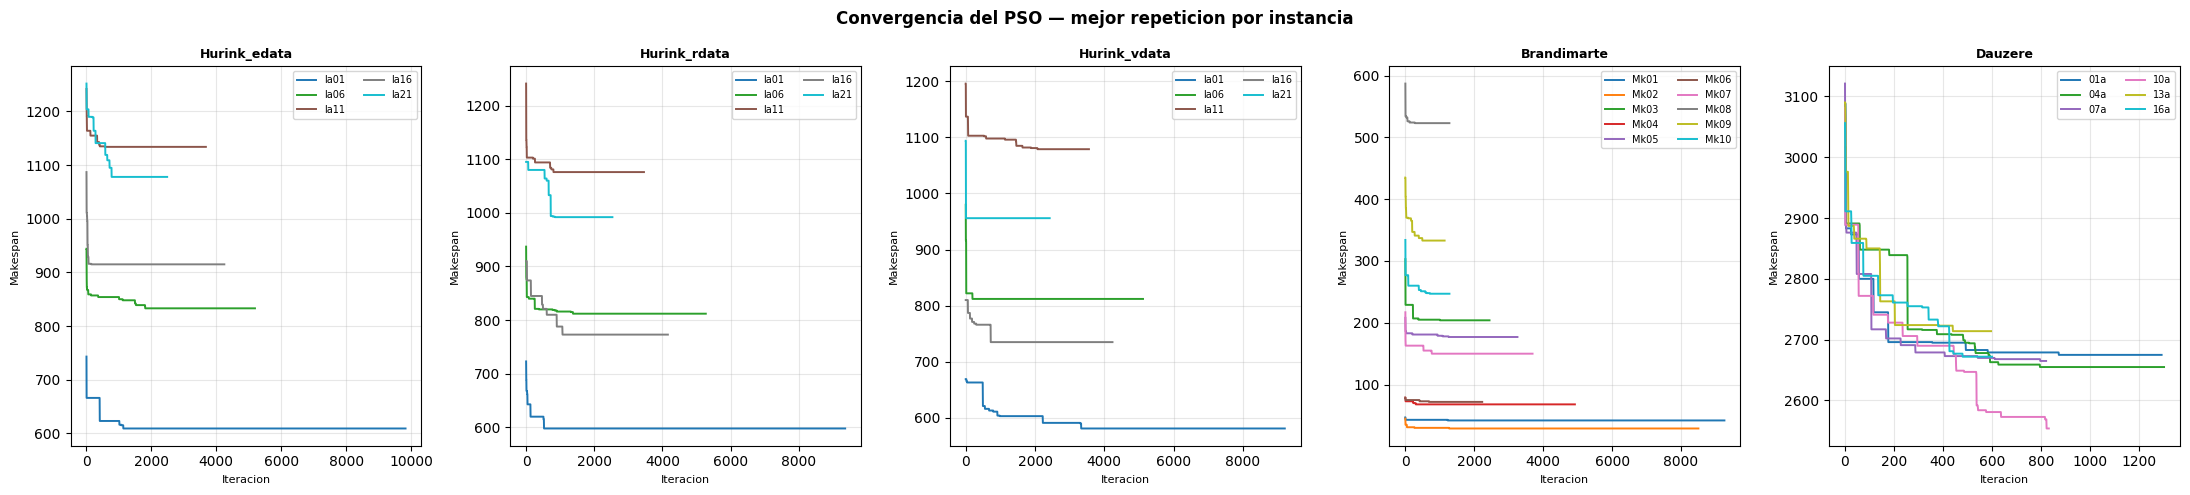

In [23]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

BENCH_ORDER = ["Hurink_edata","Hurink_rdata","Hurink_vdata",
               "Brandimarte","Dauzere"]
fig, axes = plt.subplots(1, 5, figsize=(22, 5))

for ax, bname in zip(axes, BENCH_ORDER):
    rows = [s for s in ALL_SUMMARY if s["benchmark"] == bname]
    cols = cm.tab10(np.linspace(0, 1, max(len(rows),1)))
    for s, col in zip(rows, cols):
        h = s["best_hist"]
        if h:
            ax.plot([x[0] for x in h], [x[1] for x in h],
                    color=col, linewidth=1.4, label=s["instance"])
    ax.set_title(bname, fontsize=9, fontweight="bold")
    ax.set_xlabel("Iteracion", fontsize=8)
    ax.set_ylabel("Makespan", fontsize=8)
    ax.legend(fontsize=7, ncol=2)
    ax.grid(alpha=0.3)

fig.suptitle("Convergencia del PSO — mejor repeticion por instancia",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, f"convergencia_{stamp}.png"),
            dpi=150, bbox_inches="tight")
plt.show()


## 9 · Gap % por instancia

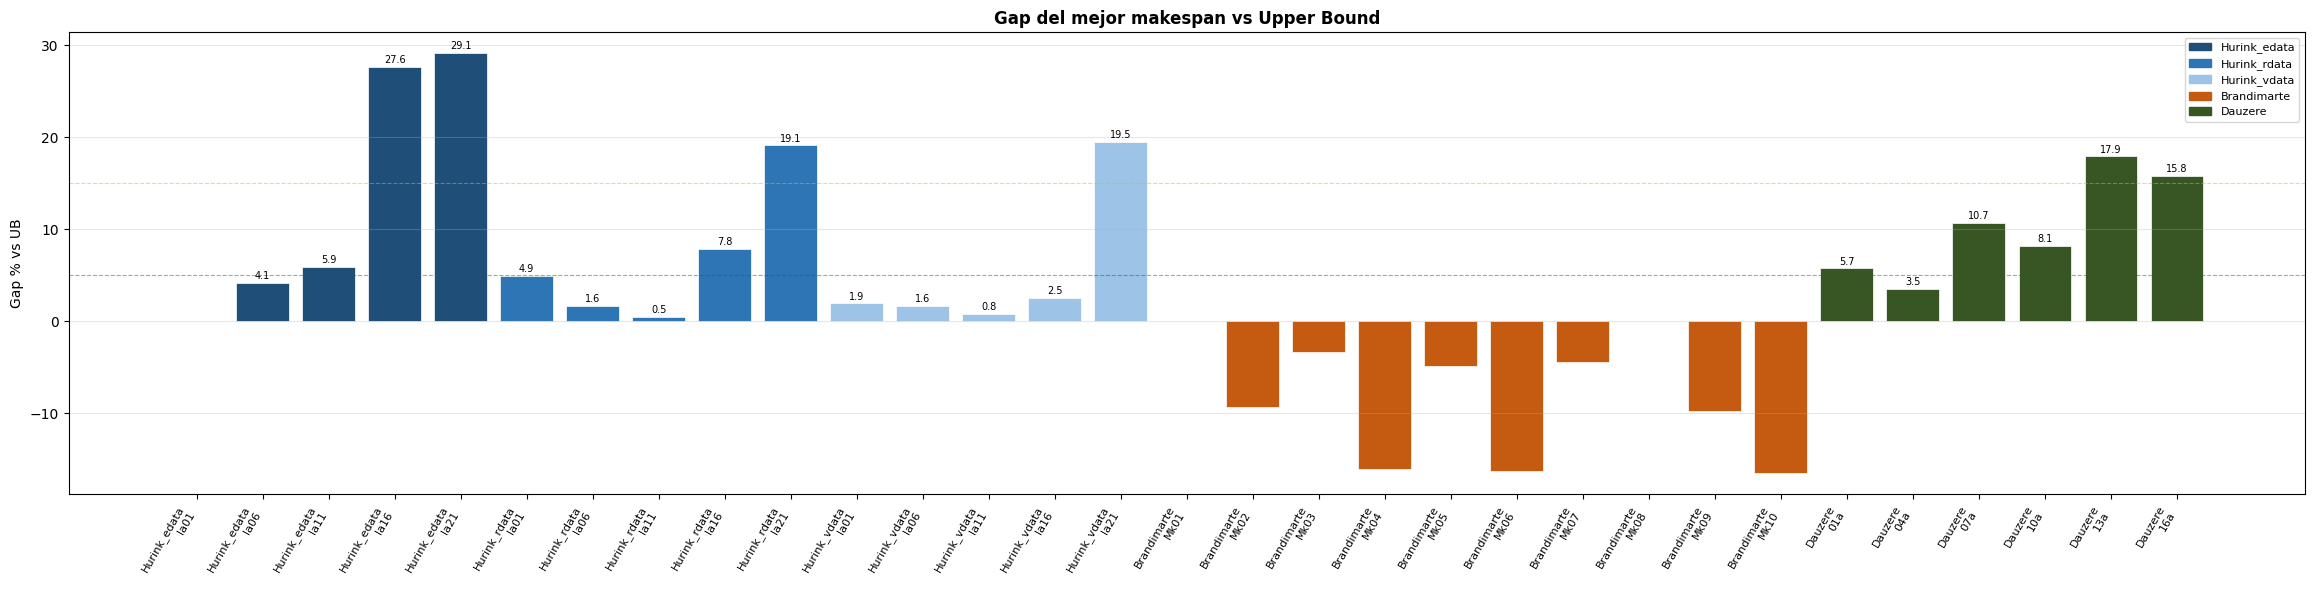

In [24]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

COLORS = {
    "Hurink_edata":"#1F4E79","Hurink_rdata":"#2E75B6","Hurink_vdata":"#9DC3E6",
    "Brandimarte":"#C55A11","Dauzere":"#375623"
}
labels = [f"{s['benchmark']}\n{s['instance']}" for s in ALL_SUMMARY]
gaps   = [s["gap_best"] for s in ALL_SUMMARY]
cols   = [COLORS[s["benchmark"]] for s in ALL_SUMMARY]
x      = np.arange(len(labels))

fig, ax = plt.subplots(figsize=(max(14, len(labels)*0.75), 6))
bars = ax.bar(x, gaps, color=cols, edgecolor="white", linewidth=0.5)
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=60, ha="right", fontsize=8)
ax.set_ylabel("Gap % vs UB")
ax.set_title("Gap del mejor makespan vs Upper Bound", fontsize=12, fontweight="bold")
for bar, g in zip(bars, gaps):
    if g > 0:
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.2,
                f"{g:.1f}", ha="center", va="bottom", fontsize=7)
ax.axhline(5,  color="green",  linestyle="--", linewidth=0.8, alpha=0.5)
ax.axhline(15, color="orange", linestyle="--", linewidth=0.8, alpha=0.5)
patches = [mpatches.Patch(color=c, label=b) for b,c in COLORS.items()]
ax.legend(handles=patches, fontsize=8)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, f"gap_{stamp}.png"),
            dpi=150, bbox_inches="tight")
plt.show()


## 10 · Mejor / Promedio / Peor vs UB

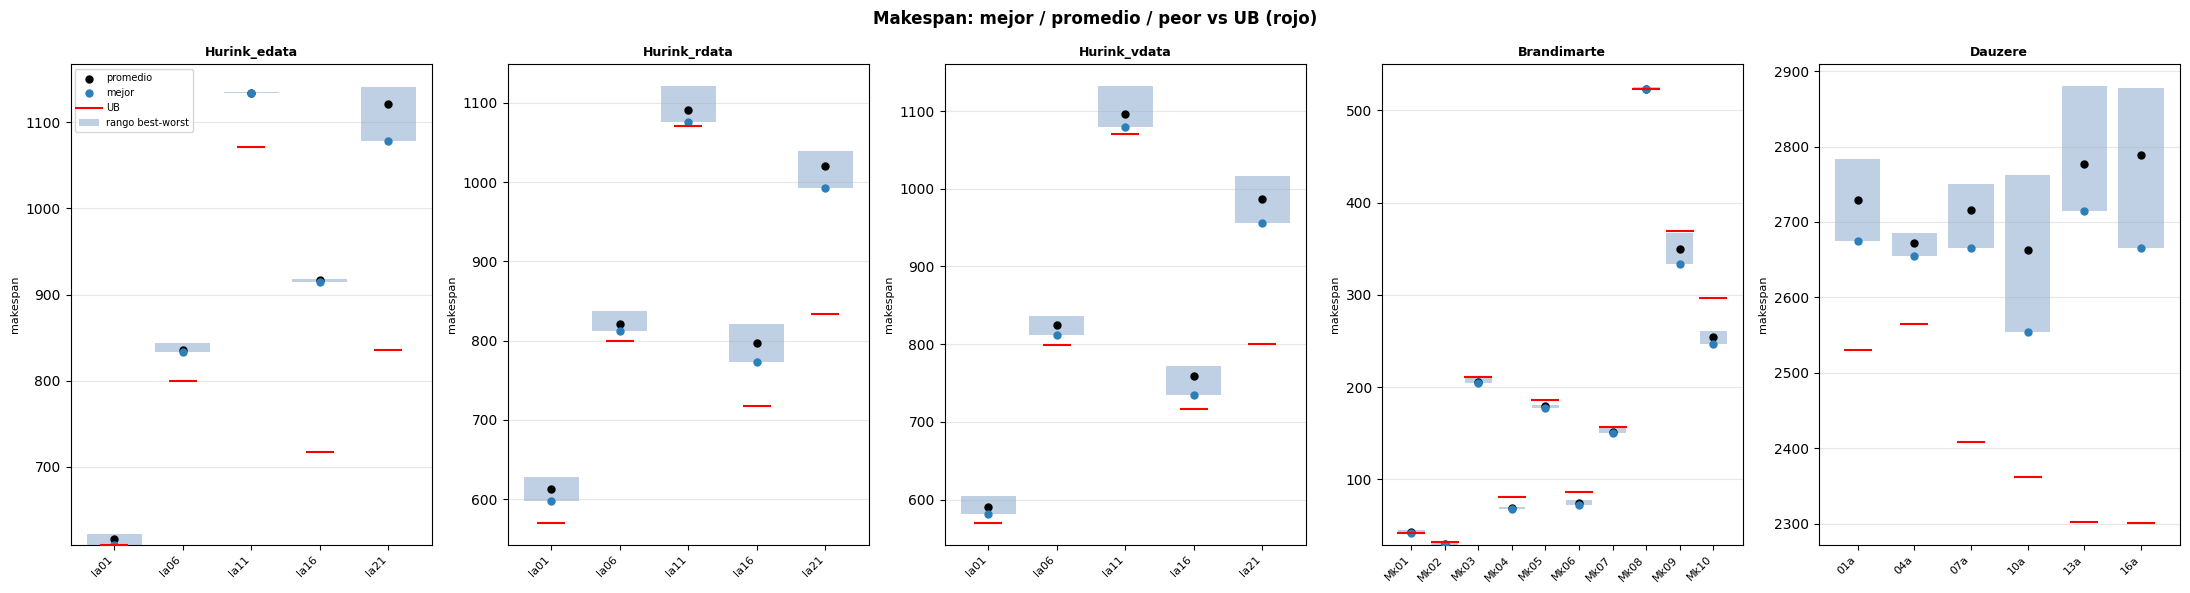

In [25]:
import matplotlib.pyplot as plt
import numpy as np

BENCH_ORDER = ["Hurink_edata","Hurink_rdata","Hurink_vdata",
               "Brandimarte","Dauzere"]
fig, axes = plt.subplots(1, 5, figsize=(22, 6))

for ax, bname in zip(axes, BENCH_ORDER):
    rows  = [s for s in ALL_SUMMARY if s["benchmark"] == bname]
    ins   = [s["instance"] for s in rows]
    best  = np.array([s["best"]  for s in rows], float)
    mean  = np.array([s["mean"]  for s in rows], float)
    worst = np.array([s["worst"] for s in rows], float)
    ub    = np.array([s["ub"]    for s in rows], float)
    x     = np.arange(len(ins))
    ax.bar(x, worst-best, bottom=best, color="#B0C4DE", alpha=0.8,
           label="rango best-worst")
    ax.scatter(x, mean,  color="black",   zorder=3, s=25, label="promedio")
    ax.scatter(x, best,  color="#2C7FB8", zorder=3, s=25, label="mejor")
    ax.scatter(x, ub,    color="red", marker="_", s=400, zorder=4, label="UB")
    ax.set_xticks(x)
    ax.set_xticklabels(ins, rotation=45, ha="right", fontsize=8)
    ax.set_title(bname, fontsize=9, fontweight="bold")
    ax.set_ylabel("makespan", fontsize=8)
    ax.grid(axis="y", alpha=0.3)
    if bname == BENCH_ORDER[0]:
        ax.legend(fontsize=7)

fig.suptitle("Makespan: mejor / promedio / peor vs UB (rojo)",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, f"best_mean_worst_{stamp}.png"),
            dpi=150, bbox_inches="tight")
plt.show()


## 11 · Boxplot por benchmark

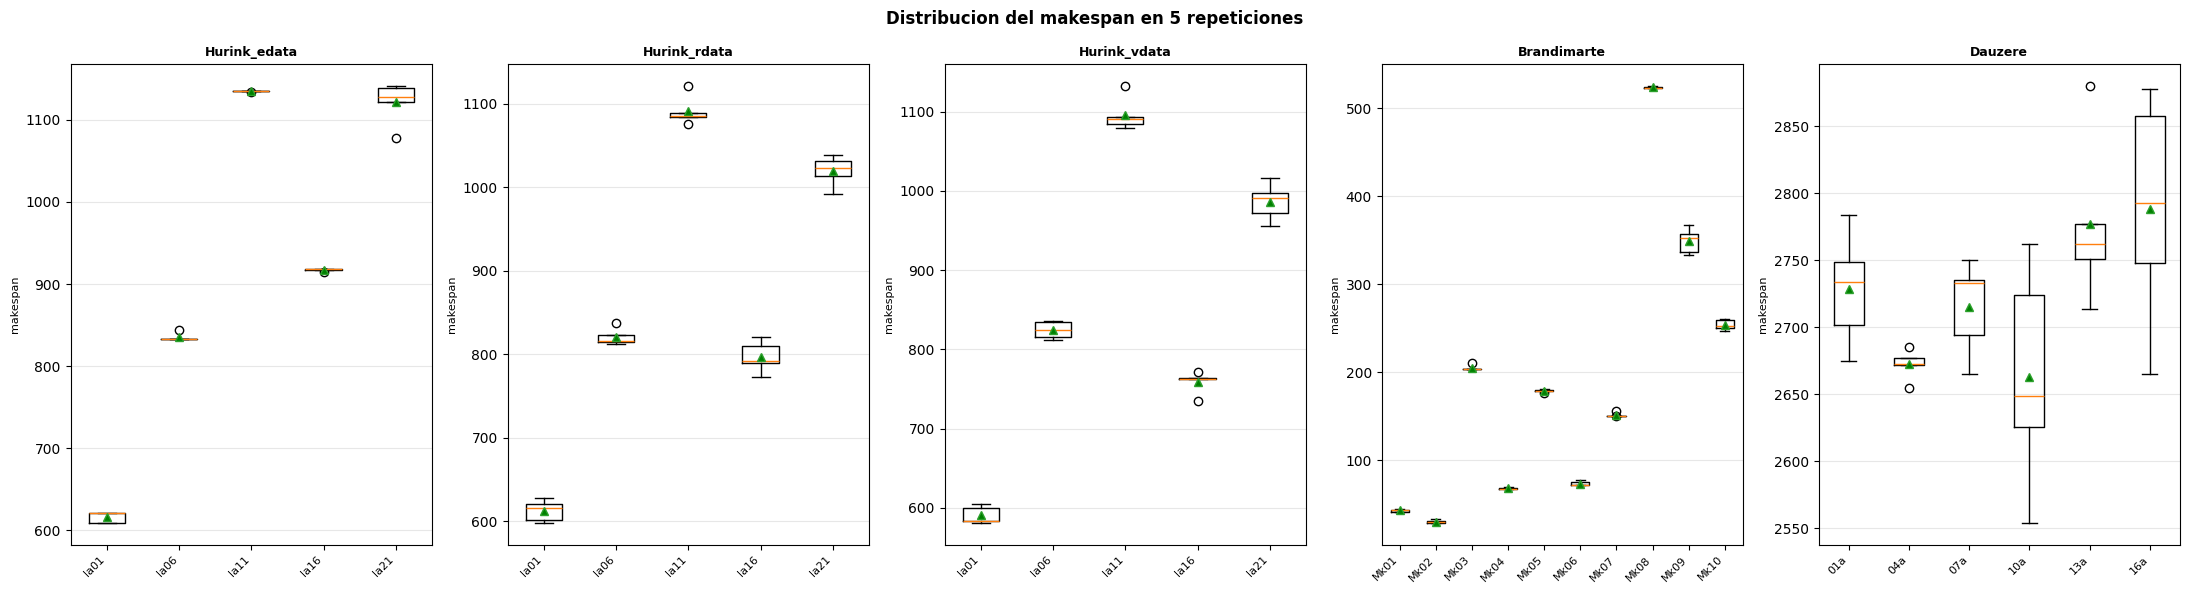

In [26]:
import matplotlib.pyplot as plt

BENCH_ORDER = ["Hurink_edata","Hurink_rdata","Hurink_vdata",
               "Brandimarte","Dauzere"]
fig, axes = plt.subplots(1, 5, figsize=(22, 6))

for ax, bname in zip(axes, BENCH_ORDER):
    rows   = [s for s in ALL_SUMMARY if s["benchmark"] == bname]
    labels = [s["instance"] for s in rows]
    data   = [
        [r["makespan"] for r in ALL_RUNS
         if r["benchmark"]==s["benchmark"] and r["instance"]==s["instance"]]
        for s in rows
    ]
    ax.boxplot(data, showmeans=True,
               meanprops={"marker":"^","markerfacecolor":"green","markersize":6})
    ax.set_xticks(range(1, len(labels)+1))
    ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=8)
    ax.set_title(bname, fontsize=9, fontweight="bold")
    ax.set_ylabel("makespan", fontsize=8)
    ax.grid(axis="y", alpha=0.3)

fig.suptitle(f"Distribucion del makespan en {N_REPS} repeticiones",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, f"boxplot_{stamp}.png"),
            dpi=150, bbox_inches="tight")
plt.show()


## 12 · Gap% promedio por benchmark

/tmp/ipykernel_9404/3057486020.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(BENCH_ORDER, rotation=20, ha="right")


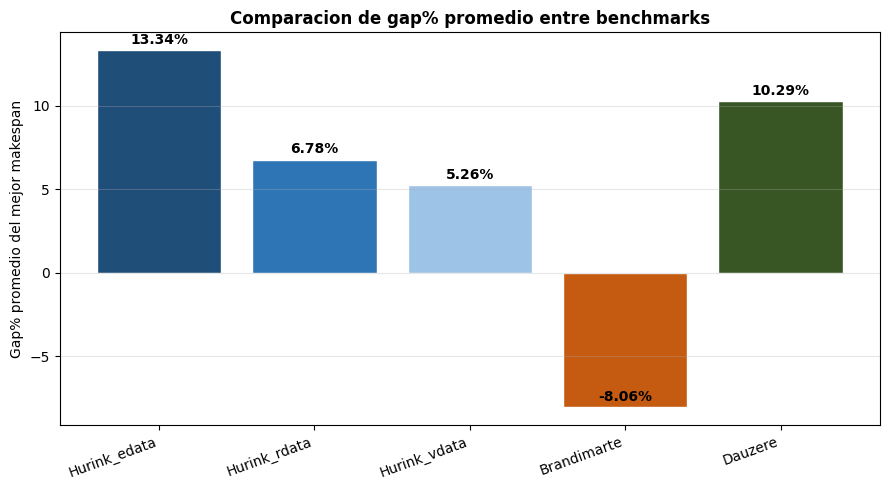

Gap% promedio por benchmark:
  Hurink_edata        : 13.34%
  Hurink_rdata        : 6.78%
  Hurink_vdata        : 5.26%
  Brandimarte         : -8.06%
  Dauzere             : 10.29%


In [27]:
import matplotlib.pyplot as plt

BENCH_ORDER = ["Hurink_edata","Hurink_rdata","Hurink_vdata",
               "Brandimarte","Dauzere"]
COLORS = ["#1F4E79","#2E75B6","#9DC3E6","#C55A11","#375623"]

avgs = []
for bname in BENCH_ORDER:
    gs = [s["gap_best"] for s in ALL_SUMMARY if s["benchmark"]==bname]
    avgs.append(round(sum(gs)/len(gs), 2) if gs else 0)

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(BENCH_ORDER, avgs, color=COLORS, edgecolor="white")
for bar, v in zip(bars, avgs):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.2,
            f"{v:.2f}%", ha="center", va="bottom",
            fontsize=10, fontweight="bold")
ax.set_ylabel("Gap% promedio del mejor makespan")
ax.set_title("Comparacion de gap% promedio entre benchmarks",
             fontsize=12, fontweight="bold")
ax.set_xticklabels(BENCH_ORDER, rotation=20, ha="right")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, f"gap_promedio_{stamp}.png"),
            dpi=150, bbox_inches="tight")
plt.show()

print("Gap% promedio por benchmark:")
for b, v in zip(BENCH_ORDER, avgs):
    print(f"  {b:<20}: {v:.2f}%")


## 13 · Diagrama de Gantt

Cambia `SEL_BENCH` y `SEL_INST` para ver cualquier instancia.


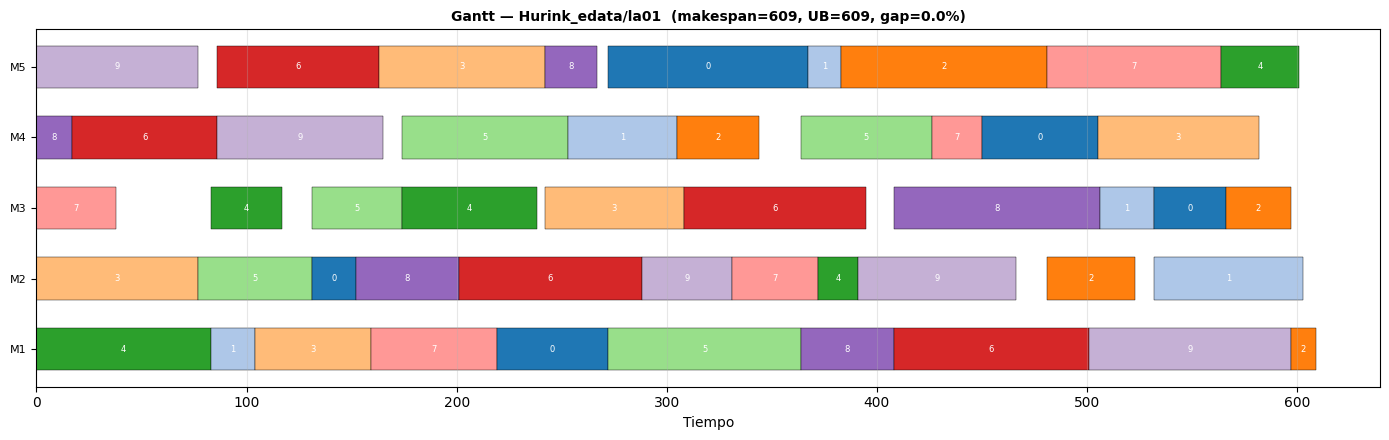

In [28]:
import matplotlib.pyplot as plt

SEL_BENCH = "Hurink_edata"
SEL_INST  = ALL_SUMMARY[0]["instance"] if ALL_SUMMARY else "la01"

row = next((s for s in ALL_SUMMARY
            if s["benchmark"]==SEL_BENCH and s["instance"]==SEL_INST), None)

if row is None:
    print(f"No encontre {SEL_BENCH}/{SEL_INST} en los resultados.")
else:
    palette = plt.get_cmap("tab20").colors
    fig, ax = plt.subplots(figsize=(14, 0.5*row["n_mach"]+2))
    for (j, o, m, s, e) in row["best_sched"]:
        ax.barh(m, e-s, left=s, height=0.6,
                color=palette[j%20], edgecolor="black", linewidth=0.3)
        ax.text((s+e)/2, m, str(j), ha="center", va="center",
                fontsize=6, color="white")
    ax.set_yticks(range(row["n_mach"]))
    ax.set_yticklabels([f"M{i+1}" for i in range(row["n_mach"])], fontsize=8)
    ax.set_xlabel("Tiempo")
    ax.set_title(
        f"Gantt — {SEL_BENCH}/{SEL_INST}  "
        f"(makespan={row['best']}, UB={row['ub']}, gap={row['gap_best']}%)",
        fontsize=10, fontweight="bold")
    ax.grid(axis="x", alpha=0.3)
    plt.tight_layout()
    plt.savefig(
        os.path.join(OUTPUT_DIR,
                     f"gantt_{SEL_BENCH}_{SEL_INST}_{stamp}.png"),
        dpi=150, bbox_inches="tight")
    plt.show()


## Archivos generados en Drive

In [29]:
print("Archivos en resultados/:")
for f in sorted(os.listdir(OUTPUT_DIR)):
    size = os.path.getsize(os.path.join(OUTPUT_DIR, f))
    print(f"  {f}  ({size:,} bytes)")


Archivos en resultados/:
  best_mean_worst_20260626_220407.png  (117,918 bytes)
  boxplot_20260626_220407.png  (121,173 bytes)
  convergencia_20260626_220407.png  (145,349 bytes)
  fjsp_pso_detalle_20260626_220407.csv  (7,362 bytes)
  fjsp_pso_reporte_20260626_220407.txt  (3,456 bytes)
  fjsp_pso_resumen_20260626_220407.csv  (2,104 bytes)
  gantt_Hurink_edata_la01_20260626_220407.png  (41,366 bytes)
  gap_20260626_220407.png  (94,874 bytes)
  gap_promedio_20260626_220407.png  (59,645 bytes)
  resultados_20260626_220407.xlsx  (22,521 bytes)
